## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [17]:
#1
import pandas as pd

df = pd.read_csv("./data/golub.csv")
df["target"] = df["cancer"].str.lower().replace({
    "allb": 0,
    "allt": 0,
    "aml": 1
})

print(df["cancer"].value_counts())
print(df[["cancer", "target"]].drop_duplicates())

cancer
allB    38
aml     25
allT     9
Name: count, dtype: int64
   cancer  target
0    allB       0
16   allT       0
20    aml       1


/var/folders/py/dcq_lkbn07v78rfmr1snh2pm0000gn/T/ipykernel_29675/2194931465.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["target"] = df["cancer"].str.lower().replace({


Mean Squared Error: 6.765406708643482e-30


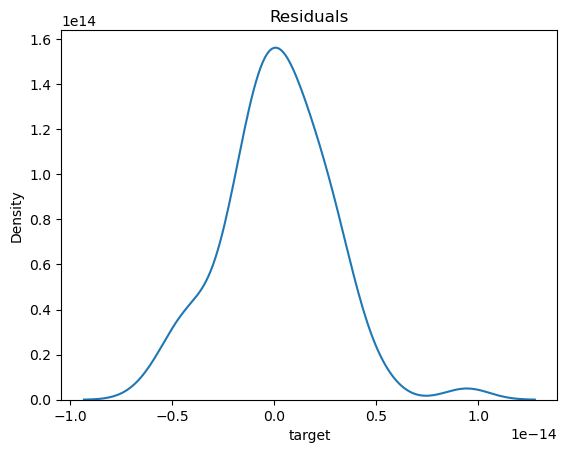

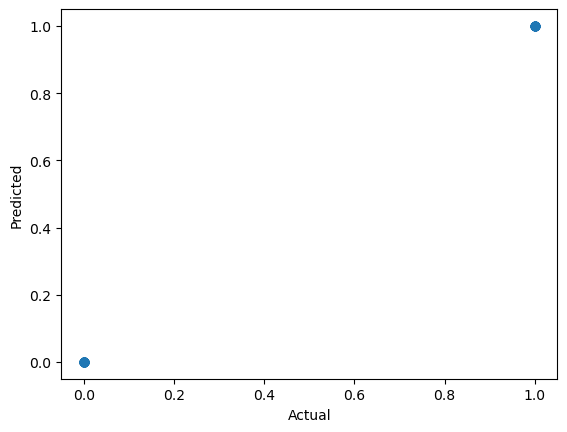

'The MSE of the model is approximately 0.0. The KDE of the residuals shows that the errors are tightly centered around 0, showing that the model predicts the data well. '

In [18]:
#2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"])
y = df["target"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

residuals = y - y_pred

sns.kdeplot(residuals)
plt.title("Residuals")
plt.show()


plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

'''The MSE of the model is approximately 0.0. The KDE of the residuals shows that the errors are tightly centered around 0, showing that the model predicts the data well. ''' 

In [19]:
#3
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = df.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"])
y = df["target"]
model = LinearRegression()
cv_scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
cv_mse = -cv_scores.mean()
print("Cross-validated MSE:", cv_mse)

'''Using cross-validation, the MSE is arounf .06. This result is high and suggests that the model is overfitting the data. This may be because there are many gene features. It fits the training data well but does not seem to generalize well to unseen data.'''

Cross-validated MSE: 0.06012309872062118


'Using cross-validation, the MSE is arounf .06. This result is high and suggests that the model is overfitting the data. This may be because there are many gene features. It fits the training data well but does not seem to generalize well to unseen data.'

Selected genes: ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']
Number of selected genes: 34
Number of discarded genes: 7095


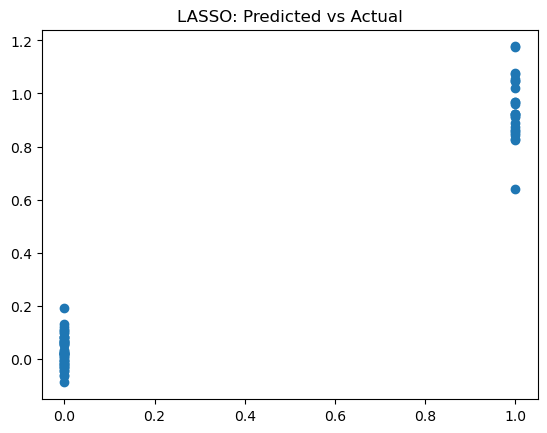

In [ ]:
#4
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X = df.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"])
y = df["target"]

lasso = LassoCV(cv=5, max_iter=10000)
lasso.fit(X, y)

selected_genes = X.columns[lasso.coef_ != 0]
print("Selected genes:", list(selected_genes))
print("Number of selected genes:", len(selected_genes))

num_discarded = X.shape[1] - len(selected_genes)
print("Number of discarded genes:", num_discarded)

y_pred = lasso.predict(X)

plt.scatter(y, y_pred)
plt.title("LASSO: Predicted vs Actual")
plt.show()

''''When using cross-validated LASSO, the scatterplot shows two veritcal groups as the actual outcomes are binary (0 or 1) while predictions are continuous.'''

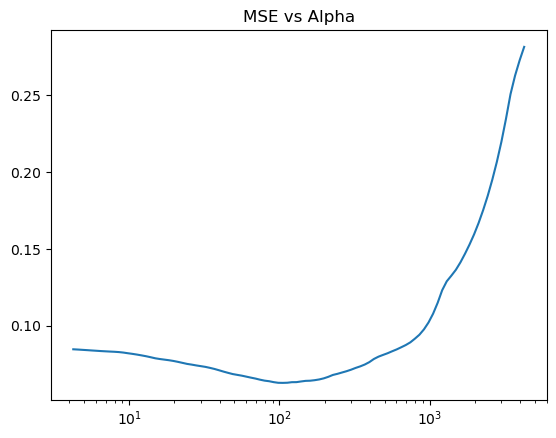

Optimal alpha: 105.24436668425457


'This plot shows how cross-validated MSE changes as the a parameter changes. The optimal value is the one that minimizes the cross-validated MSE, which I calculated to be 105.24436668425457. '

In [23]:
#5 
import numpy as np

X = df.drop(columns=["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"])
y = df["target"]
lasso_cv = LassoCV(cv=5, max_iter=10000)
lasso_cv.fit(X, y)
alphas = lasso_cv.alphas_
mse_path = lasso_cv.mse_path_.mean(axis=1)
plt.plot(alphas, mse_path)
plt.xscale("log")
plt.title("MSE vs Alpha")
plt.show()
print("Optimal alpha:", lasso_cv.alpha_)
'''This plot shows how cross-validated MSE changes as the a parameter changes. The optimal value is the one that minimizes the cross-validated MSE, which I calculated to be 105.24436668425457. '''

#6.

Linear regression performs almost perfectly on the training set because it has more gene features than samples. However, this model leads to overfitting, where the model captures noise rather than underlying patterns. The LASSO applies a penalty that shrinks some coefficients to zero and selects a smaller set of genes. This prevents overfitting and leads to better performance on unseen data. 

7.
Regularization methods are more suited for precision medicine as they involve many features and few samples. Methods like LASSO help reduce overfitting and make models more stable. This is crucial for personalized treatment decisions and when selecting only important variables.

8. 
One risk of LASSO is that it may exclude relevant variables if they are not strongly correlated or if they are too highly correlated. This could overlook important health or biological factors, potentially compromising the accuracy of the factors. The model could also capture correlations rather than causal relationships and lead to misleading conclusions about treatments. 